# Multi-modal Factor Analysis of Electrophysiological and Biophysical Data

This notebook performs multi-modal factor analysis (MCFA) on electrophysiological, biophysical, and spike-triggered average (STA) datasets. The workflow includes:

- Loading and preprocessing datasets for excitatory and inhibitory neuron populations.
- Selecting relevant features and normalizing data.
- Fitting MCFA models to partition shared and modality-specific variance.
- Visualizing explained variance, feature importance, and latent embeddings.
- Comparing structure across modalities and cell types.

Figures and results are saved for publication. All code and analyses are reproducible and modular for further exploration.

In [2]:
import numpy as np

import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.preprocessing import normalize

import torch
import umap

# from mcfa import mcfa_model
# from mcfa import gsea
from scipy import stats
import seaborn as sns
from sklearn import linear_model
from sklearn import metrics
from sklearn import preprocessing
from sklearn import model_selection
from statsmodels.stats import multitest
from single_cell_analysis.pcca_utils import *

c:\Users\Nishant Joshi\Downloads\Old_code\repo\single_cell_analysis\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from os import path
import sys
sys.path.append('C:/Users/Nishant Joshi/Downloads/Old_code/repo/single_cell_analysis/scripts')
from single_cell_analysis.utils import loadmatInPy

In [5]:
data_path = 'G:/My Drive/Data For Publication/'


In [6]:
ephys = pd.read_pickle(data_path+"CCA/ephys_with_labels.p")
# ephys = ephys.drop_duplicates('exp_name')
bio = pd.read_pickle(data_path+"/CCA/biophys_with_labels.pkl")
bio = bio.drop_duplicates('exp_name')
sta = pd.read_pickle(data_path+"/CCA/sta_with_labels.pkl")
sta = sta.drop_duplicates('exp_name')
# sta_fleur = pd.read_pickle('D:/CurrentClamp/all_stas_fleur.pkl')
# sta_fleur = sta_fleur.drop_duplicates('exp_name')
# sta_fleur = sta_fleur[sta_fleur.exp_name.isin(sta.exp_name)]

In [7]:
discarded_exps = ['xuan_151118_E1',
'xuan_15319_E1',
'xuan_20919_E2',
'xuan_27919_E1',
'xuan_27919_E2',
'xuan_27919_E3',
'NC_20717_E5' ,
'NC_25717_E2',
'payam_31019_E5',
'payam_101019_E5',
'NC_24717_E1',
'xuan_27319_E4',
'xuan_23119_E2',
'xuan_3419_E2',
'xuan_22319_E1',
'xuan_19319_E4',
'xuan_22319_E4',
'xuan_26319_E4']

In [ ]:
df_ephys = pd.read_pickle("D:/FN_analysed_feat_set/Ephys_collection_all_exps_all_conds_spikes_calculated_5ms.pkl")
df_bio   = pd.read_pickle("D:/Biophysical_cluster/rect_bio_all_feats.pkl")
df_sta   = pd.read_pickle('D:/CurrentClamp/all_stas_hidden_spikes_computed.pkl')


In [ ]:
df_ephys = df_ephys[~df_ephys.exp_name.isin(discarded_exps)]
df_bio = df_bio[~df_bio.exp_name.isin(discarded_exps)]
df_sta = df_sta[~df_sta.exp_name.isin(discarded_exps)]

## Data for second trial bootstrapping

In [ ]:
np.unique(df_ephys[df_ephys.cond != 'acsf'].trialnr, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=int64),
 array([ 18, 183, 134,  20,  14,   9,   7,   6,   2], dtype=int64))

In [ ]:
ephys_exc  = df_ephys[df_ephys.ei_labels==1] 
ephys_inh  = df_ephys[df_ephys.ei_labels==0] 

bio_exc =  df_bio[df_bio.ei_labels==1]
bio_inh =  df_bio[df_bio.ei_labels==0]

bio_exc = bio_exc[bio_exc.r_squared_V>0.7]
bio_inh = bio_inh[bio_inh.r_squared_V>0.7]

sta_exc = df_sta[df_sta.ei_label==1]
sta_inh = df_sta[df_sta.ei_label==0]


exc_exps = list(set(sta_exc.exp_name) & set(bio_exc.exp_name) & set(ephys_exc.exp_name))
inh_exps = list(set(sta_inh.exp_name) & set(bio_inh.exp_name) & set(ephys_inh.exp_name))


ephys_exc = ephys_exc[ephys_exc.exp_name.isin(exc_exps)]
ephys_inh = ephys_inh[ephys_inh.exp_name.isin(inh_exps)]


ephys_exc_all = df_ephys[df_ephys.exp_name.isin(exc_exps)]
ephys_inh_all = df_ephys[df_ephys.exp_name.isin(inh_exps)]


bio_exc = bio_exc[bio_exc.exp_name.isin(exc_exps)]
bio_inh = bio_inh[bio_inh.exp_name.isin(inh_exps)]

bio_exc_all = df_bio[df_bio.exp_name.isin(exc_exps)]
bio_inh_all = df_bio[df_bio.exp_name.isin(inh_exps)]

sta_exc = sta_exc[sta_exc.exp_name.isin(exc_exps)]
sta_inh = sta_inh[sta_inh.exp_name.isin(inh_exps)]

sta_exc_all = df_sta[df_sta.exp_name.isin(exc_exps)]
sta_inh_all = df_sta[df_sta.exp_name.isin(inh_exps)]

sta_exc_all_trial2 = sta_exc_all[sta_exc_all.cond=='acsf'][sta_exc_all.trial==1]
sta_inh_all_trial2 = sta_inh_all[sta_inh_all.cond=='acsf'][sta_inh_all.trial==1]

bio_exc_all_trial2 = bio_exc_all[bio_exc_all.cond=='acsf'][bio_exc_all.trial==1]
bio_inh_all_trial2 = bio_inh_all[bio_inh_all.cond=='acsf'][bio_inh_all.trial==1]

ephys_exc_all_trial2 = ephys_exc_all[ephys_exc_all.cond=='acsf'][ephys_exc_all.trialnr==1]
ephys_inh_all_trial2 = ephys_inh_all[ephys_inh_all.cond=='acsf'][ephys_inh_all.trialnr==1] 

<ipython-input-10-bd01e40a011d>:38: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sta_exc_all_trial2 = sta_exc_all[sta_exc_all.cond=='acsf'][sta_exc_all.trial==1]
<ipython-input-10-bd01e40a011d>:39: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sta_inh_all_trial2 = sta_inh_all[sta_inh_all.cond=='acsf'][sta_inh_all.trial==1]
<ipython-input-10-bd01e40a011d>:41: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bio_exc_all_trial2 = bio_exc_all[bio_exc_all.cond=='acsf'][bio_exc_all.trial==1]
<ipython-input-10-bd01e40a011d>:42: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bio_inh_all_trial2 = bio_inh_all[bio_inh_all.cond=='acsf'][bio_inh_all.trial==1]
<ipython-input-10-bd01e40a011d>:44: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ephys_exc_all_trial2 = ephys_exc_all[ephys_exc_all.cond=='acsf'][ephys_exc_all.trialnr==1]
<ipython-input-

## Entire dataset

In [ ]:
ephys_exc  = ephys[~ephys.labels_wave.isin([0,4,5])] 
ephys_inh  = ephys[ephys.labels_wave.isin([0,4,5])] 


bio_exc =  bio[bio.labels_wave==1]
bio_inh =  bio[bio.labels_wave==0]

bio_exc = bio_exc[bio_exc.r_squared_V>0.7]
bio_inh = bio_inh[bio_inh.r_squared_V>0.7]

sta_exc = sta[sta.labels_wave==1]
sta_inh = sta[sta.labels_wave==0]

sta_exc = sta[sta.labels_wave==1]
sta_inh = sta[sta.labels_wave==0]



exc_exps = list(set(sta_exc.exp_name) & set(bio_exc.exp_name) & set(ephys_exc.exp_name))
inh_exps = list(set(sta_inh.exp_name) & set(bio_inh.exp_name) & set(ephys_inh.exp_name))


ephys_exc = ephys_exc[ephys_exc.exp_name.isin(exc_exps)]
ephys_inh = ephys_inh[ephys_inh.exp_name.isin(inh_exps)]


ephys_exc_all = df_ephys[df_ephys.exp_name.isin(exc_exps)]
ephys_inh_all = df_ephys[df_ephys.exp_name.isin(inh_exps)]



bio_exc = bio_exc[bio_exc.exp_name.isin(exc_exps)]
bio_inh = bio_inh[bio_inh.exp_name.isin(inh_exps)]

bio_exc_all = df_bio[df_bio.exp_name.isin(exc_exps)]
bio_inh_all = df_bio[df_bio.exp_name.isin(inh_exps)]

sta_exc = sta_exc[sta_exc.exp_name.isin(exc_exps)]
sta_inh = sta_inh[sta_inh.exp_name.isin(inh_exps)]

sta_exc_all = df_sta[df_sta.exp_name.isin(exc_exps)]
sta_inh_all = df_sta[df_sta.exp_name.isin(inh_exps)]

In [ ]:
len(ephys_exc), len(ephys_inh)

(183, 121)

In [ ]:
# idx = np.array(-1*(np.unique(bio_exc_all.exp_name,return_counts=True)[1] - np.unique(ephys_exc_all.exp_name,return_counts=True)[1] ),dtype=bool)
# np.array(np.unique(bio_exc_all.exp_name))[idx]
bio_exc_all = bio_exc_all[bio_exc_all.exp_name!='NC_101017_E5']
ephys_exc_all = ephys_exc_all[ephys_exc_all.exp_name!='NC_101017_E5']
sta_exc_all = sta_exc_all[sta_exc_all.exp_name!='NC_101017_E5']



In [ ]:
print(len(sta_exc_all), len(bio_exc_all), len(ephys_exc_all))
print(len(sta_inh_all), len(bio_inh_all), len(ephys_inh_all))

469 469 469
320 320 320


In [ ]:
conds  = list(set(df_ephys.cond))
for cond in conds:
    print(cond, len(df_ephys[df_ephys.cond==cond].drop_duplicates('exp_name')))

d2 59
dopamine 40
m1-ant 23
m1-ago 41
m1-ago+ant 46
acsf_bic 17
cirazoline 34
acsf 288
sag 23
d1 54


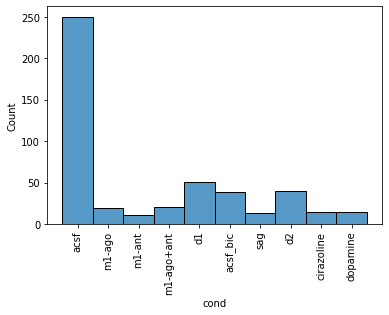

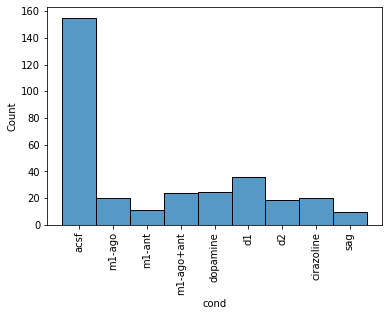

In [ ]:
sns.histplot(df_ephys[df_ephys.exp_name.isin(exc_exps)].cond)
plt.xticks(rotation=90)
plt.show()

sns.histplot(df_ephys[df_ephys.exp_name.isin(inh_exps)].cond)
plt.xticks(rotation=90)
plt.show()

In [ ]:
cols_ephys = ['current_at_first_spike', 'ap_count', 'fr', 'inst_fr',
       'time_to_first_spike', 'mean_isi', 'median_isi', 'max_isi', 'min_isi',
       'first_thr', 'mean_thr', 'median_thr', 'min_thr', 'max_thr',
       'mean_width', 'median_width', 'max_width', 'min_width',
       'mean_amplitude', 'median_amplitude', 'min_amplitude', 'max_amplitude',]
cols_bio = ['tau_m (ms)', 'C (nF)', 'gl (nS)', 'El (mV)', 'Vr (mV)', 'Vt* (mV)', 'DV (mV)',]

# Neuromodulators

In [ ]:
df_sta_exc = pd.DataFrame(columns=np.arange(np.vstack(sta_exc['sta'].to_numpy()).shape[1]))
df_sta_exc[df_sta_exc.columns] = normalize(np.vstack(sta_exc['sta'].to_numpy()))
bio_exc[cols_bio] = bio_exc[cols_bio].to_numpy(dtype=np.float32)

df_eta_exc = pd.DataFrame(columns=np.arange(10759))

df_eta_exc[df_eta_exc.columns]  = normalize(np.float32(np.vstack(bio_exc['eta'].to_numpy())))

ephys_exc[cols_ephys] = ephys_exc[cols_ephys].to_numpy(dtype=np.float32)

In [ ]:
df_sta_inh = pd.DataFrame(columns=np.arange(np.vstack(sta_exc['sta'].to_numpy()).shape[1]))
df_sta_inh[df_sta_inh.columns] =normalize(np.vstack(sta_inh['sta'].to_numpy()))
bio_inh[cols_bio] = bio_inh[cols_bio].to_numpy(dtype=np.float32)

df_eta_inh = pd.DataFrame(columns=np.arange(10759))
df_eta_inh[df_eta_inh.columns]  =  normalize(np.float32(np.vstack(bio_inh['eta'].to_numpy())))
ephys_inh[cols_ephys] = ephys_inh[cols_ephys].to_numpy(dtype=np.float32)

## D1

exc 50
inh 36


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

   dataset     Space  Variance explained
0    ephys    Shared            0.410585
1      bio    Shared            0.495963
3      eta    Shared            0.069063
2      sta    Shared            0.095269
4    ephys  Specific            0.000058
5      bio  Specific            0.100704
7      eta  Specific            0.057486
6      sta  Specific            0.739595
8    ephys  Residual            0.589357
9      bio  Residual            0.403333
11     eta  Residual            0.873451
10     sta  Residual            0.165136
   dataset     Space  Variance explained
0    ephys    Shared            0.323926
1      bio    Shared            0.252732
3      eta    Shared            0.444747
2      sta    Shared            0.462345
4    ephys  Specific            0.008296
5      bio  Specific            0.039880
7      eta  Specific            0.116295
6      sta  Specific            0.483897
8    ephys  Residual            0.667778
9      bio  Residual            0.707388
11     eta  Resi

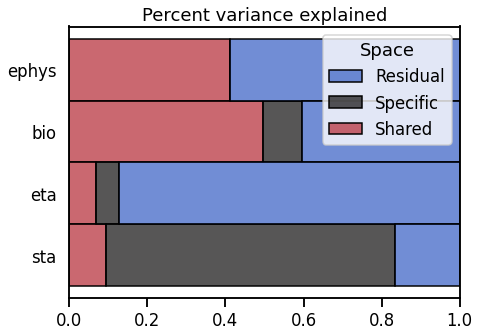

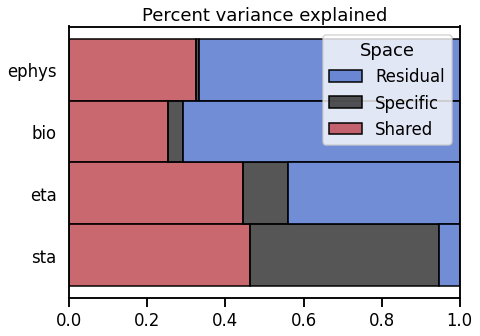

In [ ]:
var_exp_totals_exc_d1,var_exp_totals_inh_d1 =  perform_MCFA('d1',save=True, savepath = 'G:/My Drive/Data For Publication/paper2/part1/')
ephys_drug_exc = return_neuromod_df(ephys_exc_all,cond=['d1'], cols=cols_ephys, df_type='ephys')
ephys_drug_inh = return_neuromod_df(ephys_inh_all,cond=['d1'], cols=cols_ephys, df_type='ephys')


In [ ]:
bootstraped_acsf_d1_exc= bootstrap_MCFA([ephys_exc , bio_exc, df_sta_exc, df_eta_exc],iters=100,sample_size=len(ephys_drug_exc))
bootstraped_acsf_d1_inh= bootstrap_MCFA([ephys_inh , bio_inh, df_sta_inh, df_eta_inh],iters=100,sample_size=len(ephys_drug_inh))

## D2

exc 40
inh 19


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

   dataset     Space  Variance explained
0    ephys    Shared            0.550132
1      bio    Shared            0.222901
3      eta    Shared            0.306855
2      sta    Shared            0.180295
4    ephys  Specific            0.002099
5      bio  Specific            0.143780
7      eta  Specific            0.167955
6      sta  Specific            0.712166
8    ephys  Residual            0.447768
9      bio  Residual            0.633319
11     eta  Residual            0.525190
10     sta  Residual            0.107539
   dataset     Space  Variance explained
0    ephys    Shared            0.240248
1      bio    Shared            0.536691
3      eta    Shared            0.389088
2      sta    Shared            0.666930
4    ephys  Specific            0.016354
5      bio  Specific            0.112797
7      eta  Specific            0.263596
6      sta  Specific            0.215494
8    ephys  Residual            0.743399
9      bio  Residual            0.350512
11     eta  Resi

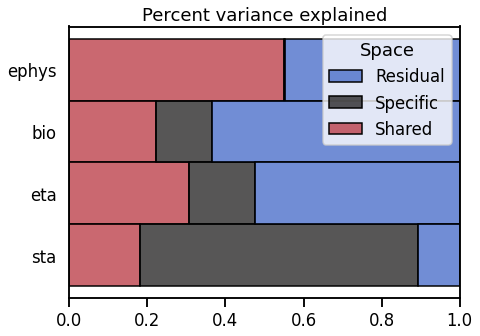

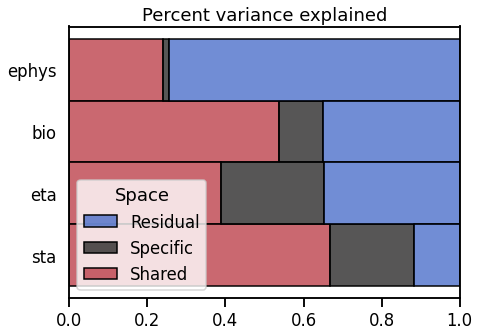

In [ ]:
var_exp_totals_exc_d2,var_exp_totals_inh_d2 = perform_MCFA('d2', save=True, savepath = 'G:/My Drive/Data For Publication/paper2/part1/')

ephys_drug_exc = return_neuromod_df(ephys_exc_all,cond=['d2'],cols=cols_ephys,df_type='ephys')
ephys_drug_inh = return_neuromod_df(ephys_inh_all,cond=['d2'],cols=cols_ephys,df_type='ephys')



## M1

exc 19
inh 20


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

   dataset     Space  Variance explained
0    ephys    Shared            0.660429
1      bio    Shared            0.263527
3      eta    Shared            0.350797
2      sta    Shared            0.069095
4    ephys  Specific            0.000012
5      bio  Specific            0.294305
7      eta  Specific            0.103259
6      sta  Specific            0.028383
8    ephys  Residual            0.339560
9      bio  Residual            0.442167
11     eta  Residual            0.545944
10     sta  Residual            0.902522
   dataset     Space  Variance explained
0    ephys    Shared            0.467960
1      bio    Shared            0.515773
3      eta    Shared            0.228307
2      sta    Shared            0.543021
4    ephys  Specific            0.063213
5      bio  Specific            0.188555
7      eta  Specific            0.506684
6      sta  Specific            0.363626
8    ephys  Residual            0.468827
9      bio  Residual            0.295672
11     eta  Resi

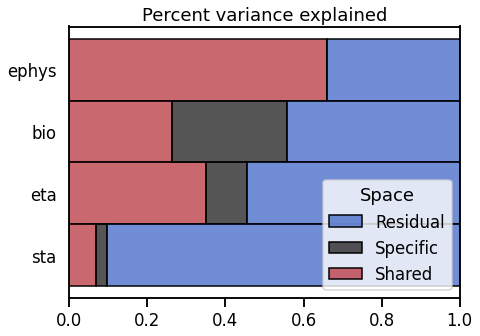

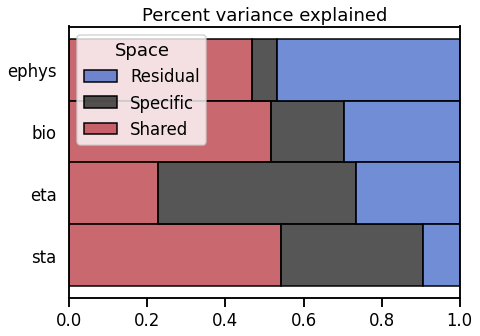

In [ ]:
var_exp_totals_exc_m1,var_exp_totals_inh_m1 = perform_MCFA('m1-ago',save=True, savepath = 'G:/My Drive/Data For Publication/paper2/part1/')


ephys_drug_exc = return_neuromod_df(ephys_exc_all,cond=['m1-ago'],cols=cols_ephys,df_type='ephys')
ephys_drug_inh = return_neuromod_df(ephys_inh_all,cond=['m1-ago'],cols=cols_ephys,df_type='ephys')



## Correct for multiple acsf trials

In [ ]:
np.random.seed(0)
rand_inds_exc = np.random.randint(0,len(ephys_exc),51)
rand_inds_inh = np.random.randint(0,len(ephys_inh),26)
# df_sta_exc.reset_index(drop='index')


### aCSF trial 1 

In [ ]:

ephys_exc  =  ephys_exc.reset_index(drop='index').loc[rand_inds_exc,:].reset_index(drop='index')
bio_exc    =    bio_exc.reset_index(drop='index').loc[rand_inds_exc,:].reset_index(drop='index')
df_sta_exc = df_sta_exc.reset_index(drop='index').loc[rand_inds_exc,:].reset_index(drop='index')
df_eta_exc = df_eta_exc.reset_index(drop='index').loc[rand_inds_exc,:].reset_index(drop='index')

ephys_inh  =  ephys_inh.reset_index(drop='index').loc[rand_inds_inh,:].reset_index(drop='index')
bio_inh    =    bio_inh.reset_index(drop='index').loc[rand_inds_inh,:].reset_index(drop='index')
df_sta_inh = df_sta_inh.reset_index(drop='index').loc[rand_inds_inh,:].reset_index(drop='index')
df_eta_inh = df_eta_inh.reset_index(drop='index').loc[rand_inds_inh,:].reset_index(drop='index')


bootstraped_acsf_m1_exc= bootstrap_MCFA([ephys_exc , bio_exc, df_sta_exc, df_eta_exc],iters=100,sample_size=19)
bootstraped_acsf_m1_inh= bootstrap_MCFA([ephys_inh , bio_inh, df_sta_inh, df_eta_inh],iters=100,sample_size=19)

(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


...

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

### aCSF trial 2

In [ ]:
ephys_drug_exc = return_neuromod_df(ephys_exc_all_trial2,cond=['acsf'],cols=cols_ephys,df_type='ephys')    
bio_drug_exc   = return_neuromod_df(bio_exc_all_trial2,cond=['acsf']  ,df_type='bio',cols=cols_bio)
eta_drug_exc   = return_neuromod_df(bio_exc_all_trial2,cond=['acsf']  ,df_type='eta')
sta_drug_exc   = return_neuromod_df(sta_exc_all_trial2,cond=['acsf']  ,df_type='sta')


# ephys_drug_exc_trial1 = return_neuromod_df(ephys_exc,cond=['acsf'],cols=cols_ephys,df_type='ephys') 
# bio_drug_exc_trial1   = return_neuromod_df(bio_exc,cond=['acsf'],df_type='bio',cols=cols_bio)
# eta_drug_exc_trial1   = df_eta_exc #return_neuromod_df(df_eta_exc,cond =['acsf'],df_type='eta')
# sta_drug_exc_trial1   = df_sta_exc #return_neuromod_df(df_sta_exc,cond=['acsf'],df_type='sta')
    
ephys_drug_inh = return_neuromod_df(ephys_inh_all_trial2,cond=['acsf'],cols=cols_ephys,df_type='ephys')    
bio_drug_inh   = return_neuromod_df(bio_inh_all_trial2,cond=['acsf']  ,df_type='bio',cols=cols_bio)
eta_drug_inh   = return_neuromod_df(bio_inh_all_trial2,cond=['acsf']  ,df_type='eta')
sta_drug_inh   = return_neuromod_df(sta_inh_all_trial2,cond=['acsf']  ,df_type='sta')

print('exc', len(ephys_drug_exc))
print('inh', len(ephys_drug_inh))

bootstraped_acsf_2_trials_exc = bootstrap_MCFA([ephys_drug_exc, bio_drug_exc, sta_drug_exc, eta_drug_exc],verbose=False,iters=100,sample_size=19)
bootstraped_acsf_2_trials_inh = bootstrap_MCFA([ephys_drug_inh, bio_drug_inh, sta_drug_inh, eta_drug_inh],verbose=False,iters=100,sample_size=19)


exc 51
inh 26
(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


...

Error in iteration 96
(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

(19, 22)
(19, 7)
(19, 2000)
(19, 10759)


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

Error in iteration 99


### Plotting the bootstraped data excitatory

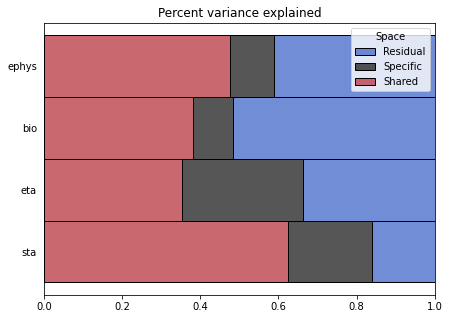

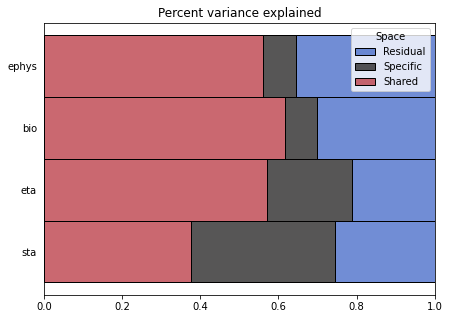

In [ ]:
temp_exc_1_trials_mean = bootstraped_acsf_m1_exc[0].copy()
temp_exc_1_trials_mean.loc[:,:] = np.mean(bootstraped_acsf_m1_exc,axis=0)
temp_exc_1_trials_mean['dataset'] = bootstraped_acsf_m1_exc[0].index
temp_exc_1_trials_mean = temp_exc_1_trials_mean.reindex(['ephys','bio','eta','sta'])
temp_exc_1_trials_mean = temp_exc_1_trials_mean.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_1_trials_std = bootstraped_acsf_m1_exc[0].copy()
temp_exc_1_trials_std.loc[:,:] = np.std(bootstraped_acsf_m1_exc,axis=0)
temp_exc_1_trials_std['dataset'] = bootstraped_acsf_m1_exc[0].index
temp_exc_1_trials_std = temp_exc_1_trials_std.reindex(['ephys','bio','eta','sta'])
temp_exc_1_trials_std = temp_exc_1_trials_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')




plot_bootstraped_data(temp_exc_1_trials_mean,save=True,cond='1st_acsf',ei_type='exc',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')

temp_inh_1_trials_mean = bootstraped_acsf_m1_inh[0].copy()
temp_inh_1_trials_mean.loc[:,:] = np.mean(bootstraped_acsf_m1_inh,axis=0)
temp_inh_1_trials_mean['dataset'] = bootstraped_acsf_m1_inh[0].index
temp_inh_1_trials_mean = temp_inh_1_trials_mean.reindex(['ephys','bio','eta','sta'])
temp_inh_1_trials_mean = temp_inh_1_trials_mean.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_inh_1_trials_std = bootstraped_acsf_m1_inh[0].copy()
temp_inh_1_trials_std.loc[:,:] = np.std(bootstraped_acsf_m1_inh,axis=0)
temp_inh_1_trials_std['dataset'] = bootstraped_acsf_m1_inh[0].index
temp_inh_1_trials_std = temp_inh_1_trials_std.reindex(['ephys','bio','eta','sta'])
temp_inh_1_trials_std = temp_inh_1_trials_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')



plot_bootstraped_data(temp_inh_1_trials_mean,save=True,cond='1st_acsf',ei_type='inh',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')



### Plotting the bootstraped data inhibitory

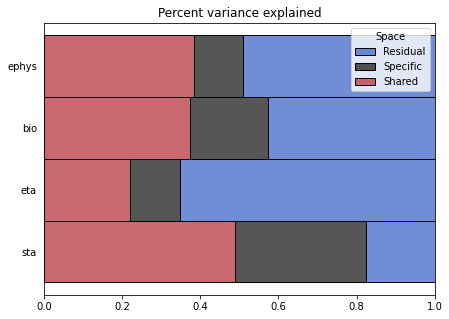

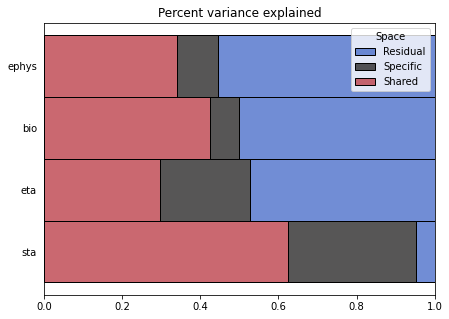

In [ ]:
temp_exc_2_trials_mean = bootstraped_acsf_2_trials_exc[0].copy()
temp_exc_2_trials_mean.loc[:,:] = np.mean(bootstraped_acsf_2_trials_exc,axis=0)
temp_exc_2_trials_mean['dataset'] = bootstraped_acsf_2_trials_exc[0].index
temp_exc_2_trials_mean = temp_exc_2_trials_mean.reindex(['ephys','bio','eta','sta'])
temp_exc_2_trials_mean = temp_exc_2_trials_mean.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_2_trials_std = bootstraped_acsf_2_trials_exc[0].copy()
temp_exc_2_trials_std.loc[:,:] = np.std(bootstraped_acsf_2_trials_exc,axis=0)
temp_exc_2_trials_std['dataset'] = bootstraped_acsf_2_trials_exc[0].index
temp_exc_2_trials_std = temp_exc_2_trials_std.reindex(['ephys','bio','eta','sta'])
temp_exc_2_trials_std = temp_exc_2_trials_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')


plot_bootstraped_data(temp_exc_2_trials_mean,save=True,cond='2nd_acsf',ei_type='exc',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')

temp_inh_2_trials_mean = bootstraped_acsf_2_trials_inh[0].copy()
temp_inh_2_trials_mean.loc[:,:] = np.mean(bootstraped_acsf_2_trials_inh,axis=0)
temp_inh_2_trials_mean['dataset'] = bootstraped_acsf_2_trials_inh[0].index
temp_inh_2_trials_mean = temp_inh_2_trials_mean.reindex(['ephys','bio','eta','sta'])
temp_inh_2_trials_mean = temp_inh_2_trials_mean.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')


temp_inh_2_trials_std = bootstraped_acsf_2_trials_inh[0].copy()
temp_inh_2_trials_std.loc[:,:] = np.std(bootstraped_acsf_2_trials_inh,axis=0)
temp_inh_2_trials_std['dataset'] = bootstraped_acsf_2_trials_inh[0].index
temp_inh_2_trials_std = temp_inh_2_trials_std.reindex(['ephys','bio','eta','sta'])
temp_inh_2_trials_std = temp_inh_2_trials_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')


plot_bootstraped_data(temp_inh_2_trials_mean,save=True,cond='2nd_acsf',ei_type='inh',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')



### Save data

In [ ]:
# len(temp_exc_2_trials)
savepath = 'G:/My Drive/Data For Publication/paper2/part1/'
 
temp_exc_1_trials_mean.to_csv(savepath + 'temp_exc_1_trials_mean.csv')
temp_inh_1_trials_mean.to_csv(savepath + 'temp_inh_1_trials_mean.csv')

temp_exc_2_trials_mean.to_csv(savepath + 'temp_exc_2_trials_mean.csv')
temp_inh_2_trials_mean.to_csv(savepath + 'temp_inh_2_trials_mean.csv')


In [ ]:
temp_inh_2_trials_std

,dataset,Space,Variance explained
0,ephys,Shared,0.170569
1,bio,Shared,0.160056
2,eta,Shared,0.104097
3,sta,Shared,0.224520
4,ephys,Specific,0.071356
5,bio,Specific,0.095573
6,eta,Specific,0.151887
7,sta,Specific,0.218668
8,ephys,Residual,0.187336
9,bio,Residual,0.155338


In [ ]:
4	ephys	Specific	07.13
0	ephys	Shared	    17.05
8	ephys	Residual	18.73
5	bio	    Specific	09.55
1	bio	    Shared	    16.00
9	bio	    Residual	15.53
6	eta	    Specific	15.18
2	eta	    Shared	    10.40
10	eta	    Residual	15.30
7	sta	    Specific	21.86
3	sta	    Shared	    22.45
11	sta	    Residual	02.85


## Mean of Bootrsapped Data

In [ ]:
# ----------------Meaning the bootstraped data------------------
temp_exc_m1 = bootstraped_acsf_m1_exc[0].copy()
temp_inh_m1 = bootstraped_acsf_m1_inh[0].copy()


temp_exc_m1.loc[:,:] = np.mean(bootstraped_acsf_m1_exc,axis=0)
temp_inh_m1.loc[:,:] = np.mean(bootstraped_acsf_m1_inh,axis=0)

temp_inh_m1['dataset'] = temp_inh_m1.index
temp_inh_m1 = temp_inh_m1.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_m1['dataset'] = temp_exc_m1.index
temp_exc_m1 = temp_exc_m1.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_m1 = temp_exc_m1.reindex([0,1,3,2,4,5,7,6,8,9,11,10])
temp_inh_m1 = temp_inh_m1.reindex([0,1,3,2,4,5,7,6,8,9,11,10])

temp_exc_m1.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_m1.csv')
temp_inh_m1.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_m1.csv')


In [ ]:
# ----------------Var the bootstraped data------------------
temp_exc_m1_std = bootstraped_acsf_m1_exc[0].copy()
temp_inh_m1_std = bootstraped_acsf_m1_inh[0].copy()


temp_exc_m1_std.loc[:,:] = np.std(bootstraped_acsf_m1_exc,axis=0)
temp_inh_m1_std.loc[:,:] = np.std(bootstraped_acsf_m1_inh,axis=0)

temp_inh_m1_std['dataset'] = temp_inh_m1_std.index
temp_inh_m1_std = temp_inh_m1_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_m1_std['dataset'] = temp_exc_m1_std.index
temp_exc_m1_std = temp_exc_m1_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_m1_std.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_m1_std.csv')
temp_inh_m1_std.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_m1_std.csv')


In [ ]:
temp_exc_d1 = bootstraped_acsf_d1_exc[0].copy()
temp_inh_d1 = bootstraped_acsf_d1_inh[0].copy()


temp_exc_d1.loc[:,:] = np.mean(bootstraped_acsf_d1_exc,axis=0)
temp_inh_d1.loc[:,:] = np.mean(bootstraped_acsf_d1_inh,axis=0)


temp_inh_d1['dataset'] = temp_inh_d1.index
temp_inh_d1 = temp_inh_d1.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_d1['dataset'] = temp_exc_d1.index
temp_exc_d1 = temp_exc_d1.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_d1 = temp_exc_d1.reindex([0,1,3,2,4,5,7,6,8,9,11,10])
temp_inh_d1 = temp_inh_d1.reindex([0,1,3,2,4,5,7,6,8,9,11,10])

temp_exc_d1.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_d1.csv')
temp_inh_d1.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_d1.csv')


temp_exc_d1_std = bootstraped_acsf_d1_exc[0].copy()
temp_inh_d1_std = bootstraped_acsf_d1_inh[0].copy()


temp_exc_d1_std.loc[:,:] = np.std(bootstraped_acsf_d1_exc,axis=0)
temp_inh_d1_std.loc[:,:] = np.std(bootstraped_acsf_d1_inh,axis=0)

temp_inh_d1_std['dataset'] = temp_inh_d1_std.index
temp_inh_d1_std = temp_inh_d1_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_d1_std['dataset'] = temp_exc_d1_std.index
temp_exc_d1_std = temp_exc_d1_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')


temp_exc_d1_std.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_d1_std.csv')
temp_inh_d1_std.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_d1_std.csv')

In [ ]:
temp_exc_d2 = bootstraped_acsf_d2_exc[0].copy()
temp_inh_d2 = bootstraped_acsf_d2_inh[0].copy()


temp_exc_d2.loc[:,:] = np.mean(bootstraped_acsf_d2_exc,axis=0)
temp_inh_d2.loc[:,:] = np.mean(bootstraped_acsf_d2_inh,axis=0)

temp_inh_d2['dataset'] = temp_inh_d2.index
temp_inh_d2 = temp_inh_d2.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_d2['dataset'] = temp_exc_d2.index
temp_exc_d2 = temp_exc_d2.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_d2 = temp_exc_d2.reindex([0,1,3,2,4,5,7,6,8,9,11,10])
temp_inh_d2 = temp_inh_d2.reindex([0,1,3,2,4,5,7,6,8,9,11,10])



temp_exc_d2.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_d2.csv')
temp_inh_d2.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_d2.csv')


temp_exc_d2_std = bootstraped_acsf_d2_exc[0].copy()
temp_inh_d2_std = bootstraped_acsf_d2_inh[0].copy()


temp_exc_d2_std.loc[:,:] = np.std(bootstraped_acsf_d2_exc,axis=0)
temp_inh_d2_std.loc[:,:] = np.std(bootstraped_acsf_d2_inh,axis=0)


temp_inh_d2_std['dataset'] = temp_inh_d2_std.index
temp_inh_d2_std = temp_inh_d2_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_d2_std['dataset'] = temp_exc_d2_std.index
temp_exc_d2_std = temp_exc_d2_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')


temp_exc_d2_std.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_d2_std.csv')
temp_inh_d2_std.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_d2_std.csv')

In [ ]:
temp_inh_d1.dataset =   temp_inh_d1.dataset.str.replace('ephys','ephys_acsf')
temp_inh_d1.dataset =   temp_inh_d1.dataset.str.replace('bio','bio_acsf')
temp_inh_d1.dataset =   temp_inh_d1.dataset.str.replace('sta','sta_acsf')
temp_inh_d1.dataset =   temp_inh_d1.dataset.str.replace('eta','eta_acsf')

temp_exc_d1.dataset =   temp_exc_d1.dataset.str.replace('ephys','ephys_acsf')
temp_exc_d1.dataset =   temp_exc_d1.dataset.str.replace('bio','bio_acsf')
temp_exc_d1.dataset =   temp_exc_d1.dataset.str.replace('sta','sta_acsf')
temp_exc_d1.dataset =   temp_exc_d1.dataset.str.replace('eta','eta_acsf')


temp_inh_d1_std.dataset =   temp_inh_d1_std.dataset.str.replace('ephys','ephys_acsf')
temp_inh_d1_std.dataset =   temp_inh_d1_std.dataset.str.replace('bio','bio_acsf')
temp_inh_d1_std.dataset =   temp_inh_d1_std.dataset.str.replace('sta','sta_acsf')
temp_inh_d1_std.dataset =   temp_inh_d1_std.dataset.str.replace('eta','eta_acsf')

temp_exc_d1_std.dataset =   temp_exc_d1_std.dataset.str.replace('ephys','ephys_acsf')
temp_exc_d1_std.dataset =   temp_exc_d1_std.dataset.str.replace('bio','bio_acsf')
temp_exc_d1_std.dataset =   temp_exc_d1_std.dataset.str.replace('sta','sta_acsf')
temp_exc_d1_std.dataset =   temp_exc_d1_std.dataset.str.replace('eta','eta_acsf')

In [ ]:
temp_exc_d2.dataset =   temp_exc_d2.dataset.str.replace('ephys','ephys_acsf')
temp_exc_d2.dataset =   temp_exc_d2.dataset.str.replace('bio','bio_acsf')
temp_exc_d2.dataset =   temp_exc_d2.dataset.str.replace('sta','sta_acsf')
temp_exc_d2.dataset =   temp_exc_d2.dataset.str.replace('eta','eta_acsf')

temp_inh_d2.dataset =   temp_inh_d2.dataset.str.replace('ephys','ephys_acsf')
temp_inh_d2.dataset =   temp_inh_d2.dataset.str.replace('bio','bio_acsf')
temp_inh_d2.dataset =   temp_inh_d2.dataset.str.replace('sta','sta_acsf')
temp_inh_d2.dataset =   temp_inh_d2.dataset.str.replace('eta','eta_acsf')


temp_exc_d2_std.dataset =   temp_exc_d2_std.dataset.str.replace('ephys','ephys_acsf')
temp_exc_d2_std.dataset =   temp_exc_d2_std.dataset.str.replace('bio','bio_acsf')
temp_exc_d2_std.dataset =   temp_exc_d2_std.dataset.str.replace('sta','sta_acsf')
temp_exc_d2_std.dataset =   temp_exc_d2_std.dataset.str.replace('eta','eta_acsf')

temp_inh_d2_std.dataset =   temp_inh_d2_std.dataset.str.replace('ephys','ephys_acsf')
temp_inh_d2_std.dataset =   temp_inh_d2_std.dataset.str.replace('bio','bio_acsf')
temp_inh_d2_std.dataset =   temp_inh_d2_std.dataset.str.replace('sta','sta_acsf')
temp_inh_d2_std.dataset =   temp_inh_d2_std.dataset.str.replace('eta','eta_acsf')


In [ ]:
temp_exc_m1.dataset =   temp_exc_m1.dataset.str.replace('ephys','ephys_acsf')
temp_exc_m1.dataset =   temp_exc_m1.dataset.str.replace('bio','bio_acsf')
temp_exc_m1.dataset =   temp_exc_m1.dataset.str.replace('sta','sta_acsf')
temp_exc_m1.dataset =   temp_exc_m1.dataset.str.replace('eta','eta_acsf')

temp_inh_m1.dataset =   temp_inh_m1.dataset.str.replace('ephys','ephys_acsf')
temp_inh_m1.dataset =   temp_inh_m1.dataset.str.replace('bio','bio_acsf')
temp_inh_m1.dataset =   temp_inh_m1.dataset.str.replace('sta','sta_acsf')
temp_inh_m1.dataset =   temp_inh_m1.dataset.str.replace('eta','eta_acsf')

temp_exc_m1_std.dataset =   temp_exc_m1_std.dataset.str.replace('ephys','ephys_acsf')
temp_exc_m1_std.dataset =   temp_exc_m1_std.dataset.str.replace('bio','bio_acsf')
temp_exc_m1_std.dataset =   temp_exc_m1_std.dataset.str.replace('sta','sta_acsf')
temp_exc_m1_std.dataset =   temp_exc_m1_std.dataset.str.replace('eta','eta_acsf')

temp_inh_m1_std.dataset =   temp_inh_m1_std.dataset.str.replace('ephys','ephys_acsf')
temp_inh_m1_std.dataset =   temp_inh_m1_std.dataset.str.replace('bio','bio_acsf')
temp_inh_m1_std.dataset =   temp_inh_m1_std.dataset.str.replace('sta','sta_acsf')
temp_inh_m1_std.dataset =   temp_inh_m1_std.dataset.str.replace('eta','eta_acsf')



In [ ]:
df_exc_d1.reset_index(drop=True).reindex([0,12,1,13,2,14,3,15,4,16,5,17,6,18,7,19,8,20,9,21,10,22,11,23])

,dataset,Space,Variance explained
0,ephys_acsf,Shared,0.373162
12,ephys,Shared,0.410573
1,bio_acsf,Shared,0.352321
13,bio,Shared,0.495894
2,eta_acsf,Shared,0.154653
14,eta,Shared,0.069040
3,sta_acsf,Shared,0.184722
15,sta,Shared,0.095248
4,ephys_acsf,Specific,0.083737
16,ephys,Specific,0.000068


In [ ]:

df_exc_d1 = pd.concat([temp_exc_d1,var_exp_totals_exc_d1],axis=0).reset_index(drop=True).reindex([0,12,1,13,2,14,3,15,4,16,5,17,6,18,7,19,8,20,9,21,10,22,11,23])
df_inh_d1 = pd.concat([temp_inh_d1,var_exp_totals_inh_d1],axis=0).reset_index(drop=True).reindex([0,12,1,13,2,14,3,15,4,16,5,17,6,18,7,19,8,20,9,21,10,22,11,23])
df_exc_m1 = pd.concat([temp_exc_m1,var_exp_totals_exc_m1],axis=0).reset_index(drop=True).reindex([0,12,1,13,2,14,3,15,4,16,5,17,6,18,7,19,8,20,9,21,10,22,11,23])
df_inh_m1 = pd.concat([temp_inh_m1,var_exp_totals_inh_m1],axis=0).reset_index(drop=True).reindex([0,12,1,13,2,14,3,15,4,16,5,17,6,18,7,19,8,20,9,21,10,22,11,23])
df_exc_d2 = pd.concat([temp_exc_d2,var_exp_totals_exc_d2],axis=0).reset_index(drop=True).reindex([0,12,1,13,2,14,3,15,4,16,5,17,6,18,7,19,8,20,9,21,10,22,11,23])
df_inh_d2 = pd.concat([temp_inh_d2,var_exp_totals_inh_d2],axis=0).reset_index(drop=True).reindex([0,12,1,13,2,14,3,15,4,16,5,17,6,18,7,19,8,20,9,21,10,22,11,23])


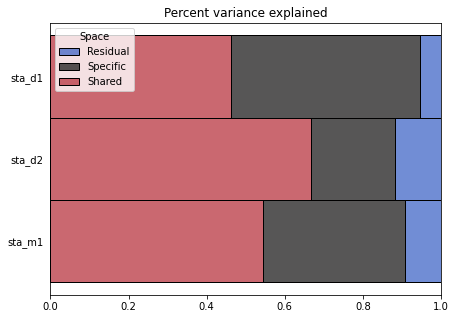

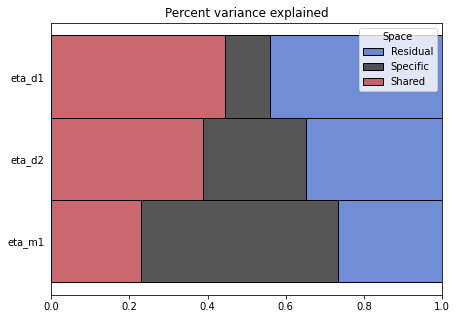

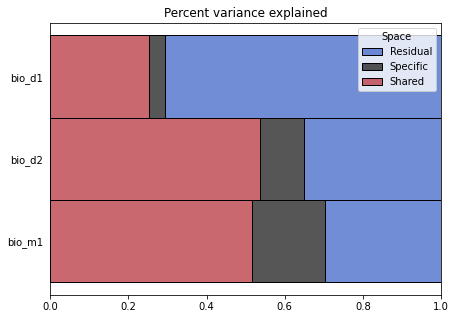

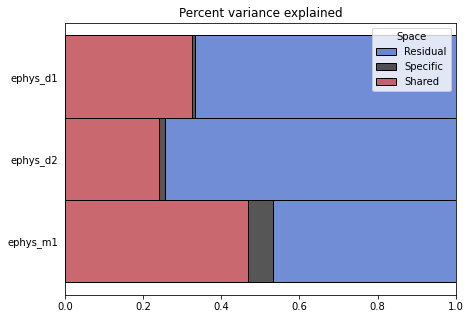

In [ ]:
for i in ['sta','eta','bio','ephys']:
    df_temp = pd.concat([var_exp_totals_inh_d1[var_exp_totals_inh_d1.dataset==i].replace(i,i+'_d1'),
    var_exp_totals_inh_d2[var_exp_totals_inh_d2.dataset==i].replace(i,i+'_d2'),
    var_exp_totals_inh_m1[var_exp_totals_inh_m1.dataset==i].replace(i,i+'_m1')
    ])
    plot_bootstraped_data(df_temp,cond=i+'_all',ei_type='exc',save=True, savepath = 'G:/My Drive/Data For Publication/paper2/part1/')

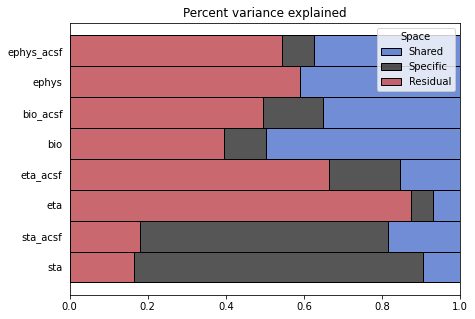

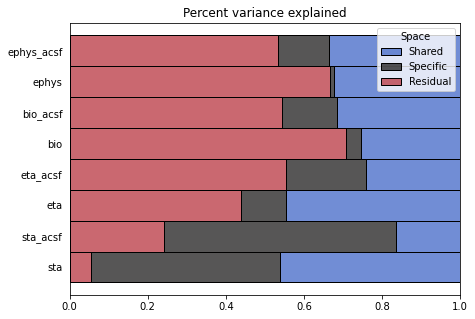

In [ ]:
plot_bootstraped_data(df_exc_d1,cond='d1',ei_type='exc',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')
plot_bootstraped_data(df_inh_d1,cond='d1',ei_type='inh',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')


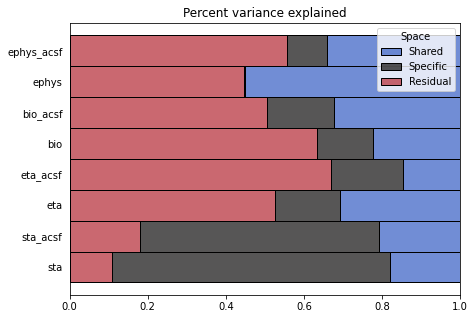

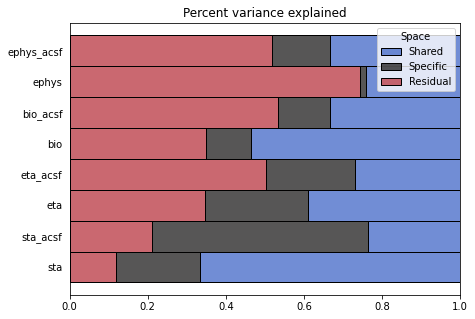

In [ ]:
plot_bootstraped_data(df_exc_d2,cond='d2',ei_type='exc',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')
plot_bootstraped_data(df_inh_d2,cond='d2',ei_type='inh',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')


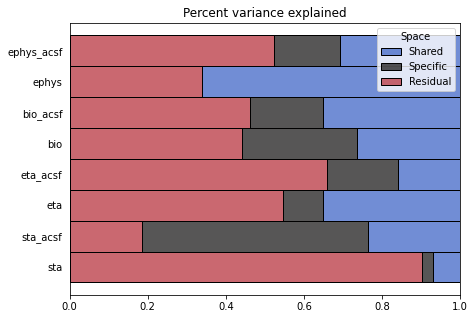

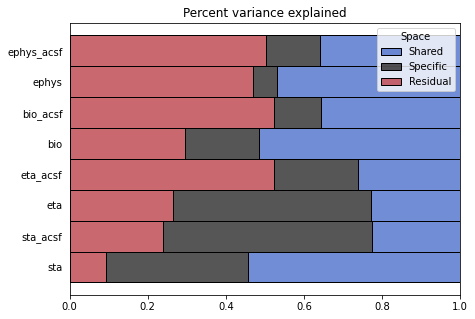

In [ ]:
plot_bootstraped_data(df_exc_m1,cond='m1',ei_type='exc',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')
plot_bootstraped_data(df_inh_m1,cond='m1',ei_type='inh',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')


In [ ]:
bootstraped_acsf_m1_exc= bootstrap_MCFA([ephys_exc , bio_exc, df_sta_exc, df_eta_exc],iters=100,sample_size=19)
bootstraped_acsf_m1_inh= bootstrap_MCFA([ephys_inh , bio_inh, df_sta_inh, df_eta_inh],iters=100,sample_size=19)

c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

Error in iteration 35


c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:246: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
c:\Users\Nishant Joshi\anaconda3\lib\site-packages\sklearn\preprocessing\_data.py:265: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. 

In [ ]:
# plot_bootstraped_data(bootstraped_acsf_m1_exc,cond='m1',ei_type='exc',savepath = 'G:/My Drive/Data For Publication/paper2/part1/')

temp_exc_all_mean = bootstraped_acsf_m1_exc[0].copy()
temp_inh_all_mean = bootstraped_acsf_m1_inh[0].copy()


temp_exc_all_mean.loc[:,:] = np.mean(bootstraped_acsf_m1_exc,axis=0)
temp_inh_all_mean.loc[:,:] = np.mean(bootstraped_acsf_m1_inh,axis=0)

temp_inh_all_mean['dataset'] = temp_inh_all_mean.index
temp_inh_all_mean = temp_inh_all_mean.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_all_mean['dataset'] = temp_exc_all_mean.index
temp_exc_all_mean = temp_exc_all_mean.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_all_mean.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_all_mean.csv')
temp_inh_all_mean.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_all_mean.csv')

temp_exc_all_std = bootstraped_acsf_m1_exc[0].copy()
temp_inh_all_std = bootstraped_acsf_m1_inh[0].copy()


temp_exc_all_std.loc[:,:] = np.std(bootstraped_acsf_m1_exc,axis=0)
temp_inh_all_std.loc[:,:] = np.std(bootstraped_acsf_m1_inh,axis=0)

temp_inh_all_std['dataset'] = temp_inh_all_std.index
temp_inh_all_std = temp_inh_all_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_all_std['dataset'] = temp_exc_all_std.index
temp_exc_all_std = temp_exc_all_std.melt(id_vars=['dataset'], var_name='Space', value_name='Variance explained')

temp_exc_all_std.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_exc_all_std.csv')
temp_inh_all_std.to_csv('G:/My Drive/Data For Publication/paper2/part1/temp_inh_all_std.csv')

In [ ]:
temp_inh_all_mean = temp_inh_all_mean.reindex([0,1,3,2,4,5,7,6,8,9,11,10])
temp_exc_all_mean = temp_exc_all_mean.reindex([0,1,3,2,4,5,7,6,8,9,11,10])

In [ ]:
ephys	Specific	09.5664
ephys	Shared	    12.0733
ephys	Residual	10.2972
bio	    Specific	10.4672
bio	    Shared	    14.8031
bio	    Residual	15.0643
eta	    Specific	16.5534
eta	    Shared	    14.6503
eta	    Residual	21.2265
sta	    Specific	25.8562
sta	    Shared	    17.2281
sta	    Residual	21.2975


## Final Plot for publication

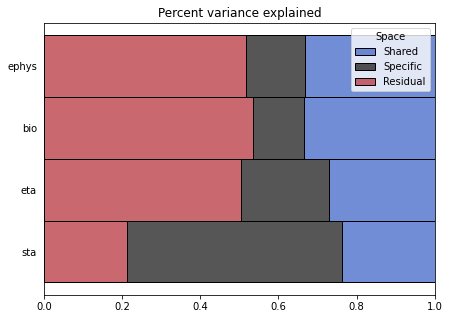

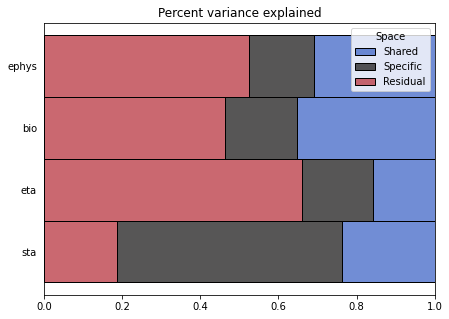

In [ ]:
plot_bootstraped_data(temp_inh_all_mean,cond='all',ei_type='inh',savepath = 'G:/My Drive/Data For Publication/paper2/part1/',save=True)
plot_bootstraped_data(temp_exc_all_mean,cond='all',ei_type='exc',savepath = 'G:/My Drive/Data For Publication/paper2/part1/',save=True)

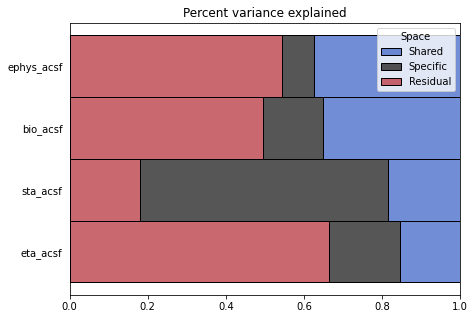

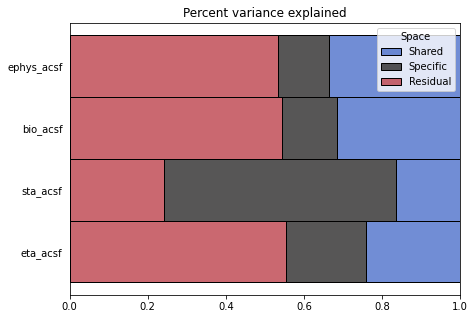

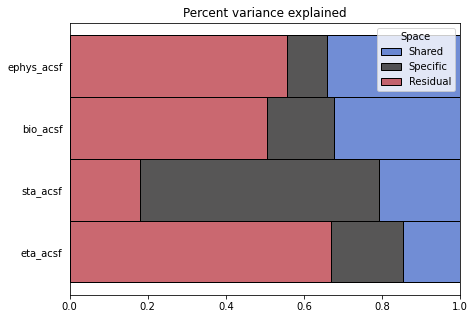

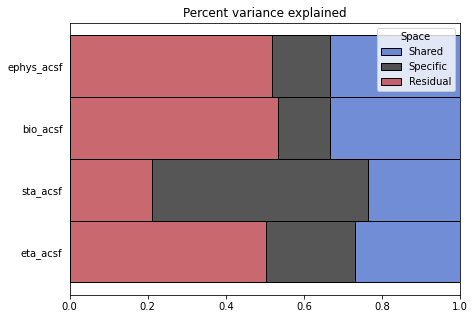

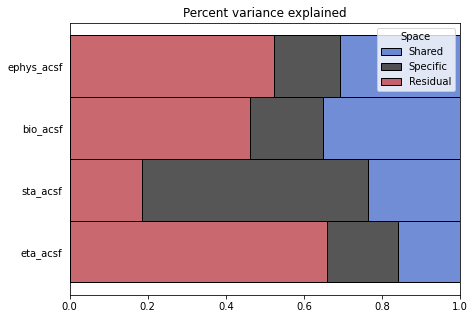

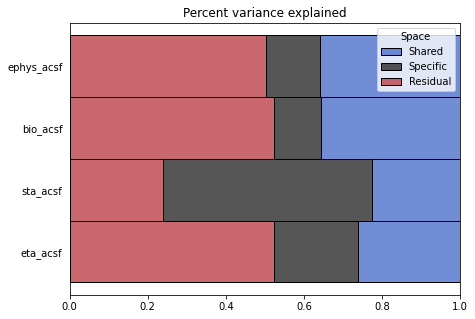

In [ ]:

# fig,ax_inh = plt.subplots(figsize=(7, 5))    

# sns.histplot(temp_inh_d1, y='dataset', hue='Space', weights='Variance explained',
#             multiple='stack', palette='icefire',ax =ax_inh)
# ax_inh.set(title='Percent variance explained', xlabel=None, ylabel=None)
# ax_inh.set_xlim(0, 1)
# ax_inh.tick_params(left=False)
# ax_inh.set_yticklabels=['ephys','bio','eta','sta']
plot_bootstraped_data(temp_exc_d1,cond='d1',ei_type='exc')
plot_bootstraped_data(temp_inh_d1,cond='d1',ei_type='inh')
plot_bootstraped_data(temp_exc_d2,cond='d2',ei_type='exc')
plot_bootstraped_data(temp_inh_d2,cond='d2',ei_type='inh')
plot_bootstraped_data(temp_exc_m1,cond='m1',ei_type='exc')
plot_bootstraped_data(temp_inh_m1,cond='m1',ei_type='inh')

In [ ]:
plot_bootstraped_data(temp_inh_d1)


In [ ]:


data_d1_exc = add_fscore(var_exp_totals_exc_d1,var_exp_totals_exc,50,183)
data_d2_exc = add_fscore(var_exp_totals_exc_d2,var_exp_totals_exc,40,183)
data_m1_exc = add_fscore(var_exp_totals_exc_m1,var_exp_totals_exc,19,183)


data_d1_exc.to_csv('G:/My Drive/Data For Publication/paper2/part1/data_d1_exc.csv')
data_d2_exc.to_csv('G:/My Drive/Data For Publication/paper2/part1/data_d2_exc.csv')
data_m1_exc.to_csv('G:/My Drive/Data For Publication/paper2/part1/data_m1_exc.csv')


In [ ]:

data_d1_inh = add_fscore(var_exp_totals_inh_d1,var_exp_totals_inh,36,183)
data_d2_inh = add_fscore(var_exp_totals_inh_d2,var_exp_totals_inh,19,183)
data_m1_inh = add_fscore(var_exp_totals_inh_m1,var_exp_totals_inh,20,183)


data_d1_inh.to_csv('G:/My Drive/Data For Publication/paper2/part1/data_d1_inh.csv')
data_d2_inh.to_csv('G:/My Drive/Data For Publication/paper2/part1/data_d2_inh.csv')
data_m1_inh.to_csv('G:/My Drive/Data For Publication/paper2/part1/data_m1_inh.csv')

In [ ]:
temp_inh_m1_std.replace('Specific','Private').reindex([4,0,8,5,1,9,6,2,10,7,3,11])

,dataset,Space,Variance explained
4,ephys_acsf,Private,0.101337
0,ephys_acsf,Shared,0.124596
8,ephys_acsf,Residual,0.104992
5,bio_acsf,Private,0.093309
1,bio_acsf,Shared,0.137648
9,bio_acsf,Residual,0.142667
6,sta_acsf,Private,0.281111
2,sta_acsf,Shared,0.206647
10,sta_acsf,Residual,0.273519
7,eta_acsf,Private,0.172720


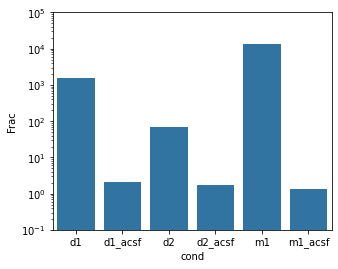

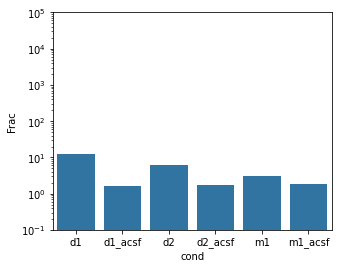

In [ ]:
frac_d1_inh   =  np.mean(var_exp_totals_inh_d1[var_exp_totals_inh_d1.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_inh_d1[var_exp_totals_inh_d1.Space=='Specific']['Variance explained'].to_numpy())
frac_d2_inh   =  np.mean(var_exp_totals_inh_d2[var_exp_totals_inh_d2.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_inh_d2[var_exp_totals_inh_d2.Space=='Specific']['Variance explained'].to_numpy())
frac_m1_inh   =  np.mean(var_exp_totals_inh_m1[var_exp_totals_inh_m1.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_inh_m1[var_exp_totals_inh_m1.Space=='Specific']['Variance explained'].to_numpy())
# frac_acsf_inh =  np.mean(var_exp_totals_inh[var_exp_totals_inh.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_inh[var_exp_totals_inh.Space=='Specific']['Variance explained'].to_numpy())

frac_d1_inh_acsf   =  np.mean(temp_inh_d1[temp_inh_d1.Space=='Shared']['Variance explained'].to_numpy()/temp_inh_d1[temp_inh_d1.Space=='Specific']['Variance explained'].to_numpy())
frac_d2_inh_acsf   =  np.mean(temp_inh_d2[temp_inh_d2.Space=='Shared']['Variance explained'].to_numpy()/temp_inh_d2[temp_inh_d2.Space=='Specific']['Variance explained'].to_numpy())
frac_m1_inh_acsf   =  np.mean(temp_inh_m1[temp_inh_m1.Space=='Shared']['Variance explained'].to_numpy()/temp_inh_m1[temp_inh_m1.Space=='Specific']['Variance explained'].to_numpy())
# frac_acsf_inh_acsf =  np.mean(var_exp_totals_inh[var_exp_totals_inh.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_inh[var_exp_totals_inh.Space=='Specific']['Variance explained'].to_numpy())




frac_d1_exc   =  np.mean(var_exp_totals_exc_d1[var_exp_totals_exc_d1.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_exc_d1[var_exp_totals_exc_d1.Space=='Specific']['Variance explained'].to_numpy())
frac_d2_exc   =  np.mean(var_exp_totals_exc_d2[var_exp_totals_exc_d2.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_exc_d2[var_exp_totals_exc_d2.Space=='Specific']['Variance explained'].to_numpy())
frac_m1_exc   =  np.mean(var_exp_totals_exc_m1[var_exp_totals_exc_m1.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_exc_m1[var_exp_totals_exc_m1.Space=='Specific']['Variance explained'].to_numpy())
# frac_acsf_exc =  np.mean(var_exp_totals_exc[var_exp_totals_exc.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_exc[var_exp_totals_exc.Space=='Specific']['Variance explained'].to_numpy())

frac_d1_exc_acsf   =  np.mean(temp_exc_d1[temp_exc_d1.Space=='Shared']['Variance explained'].to_numpy()/temp_exc_d1[temp_exc_d1.Space=='Specific']['Variance explained'].to_numpy())
frac_d2_exc_acsf   =  np.mean(temp_exc_d2[temp_exc_d2.Space=='Shared']['Variance explained'].to_numpy()/temp_exc_d2[temp_exc_d2.Space=='Specific']['Variance explained'].to_numpy())
frac_m1_exc_acsf   =  np.mean(temp_exc_m1[temp_exc_m1.Space=='Shared']['Variance explained'].to_numpy()/temp_exc_m1[temp_exc_m1.Space=='Specific']['Variance explained'].to_numpy())
# frac_acsf_exc_acsf =  np.mean(var_exp_totals_exc[var_exp_totals_exc.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_exc[var_exp_totals_exc.Space=='Specific']['Variance explained'].to_numpy())





df_frac = {'Frac':[frac_d1_inh,
                   frac_d1_inh_acsf,
                   frac_d2_inh,
                   frac_d2_inh_acsf,
                   frac_m1_inh,
                   frac_m1_inh_acsf,
                   frac_d1_exc,
                   frac_d1_exc_acsf,
                   frac_d2_exc,
                   frac_d2_exc_acsf,
                   frac_m1_exc,
                   frac_m1_exc_acsf],
                   }

df_frac = pd.DataFrame(df_frac)
df_frac['cond'] = ['d1',
                    'd1_acsf',
                    'd2',
                    'd2_acsf',
                    'm1',
                    'm1_acsf',
                    'd1',
                    'd1_acsf',
                    'd2',
                    'd2_acsf',
                    'm1',
                    'm1_acsf']
df_frac['cell_type'] = ['inh','inh','inh','inh','inh','inh','exc','exc','exc','exc','exc','exc']
fig,ax = plt.subplots(figsize=(5,4))

sns.barplot(data=df_frac[df_frac.cell_type=='exc'],x='cond',y='Frac',ax=ax,log_scale=True,bottom=0.1)
ax.set_yscale('log')
ax.set(ylim=(0.1, 100000))

plt.savefig('G:/My Drive/Data For Publication/paper2/part1/frac_shared_specific_exc.pdf',dpi=200,bbox_inches='tight')
plt.show()
fig,ax = plt.subplots(figsize=(5,4))

sns.barplot(data=df_frac[df_frac.cell_type=='inh'],x='cond',y='Frac',ax=ax,log_scale=True,bottom=0.1)
# plt.yscale('log')

ax.set(ylim=(0.1, 100000))
ax.set_yscale('log')
plt.savefig('G:/My Drive/Data For Publication/paper2/part1/frac_shared_specific_inh.pdf',dpi=200,bbox_inches='tight')
plt.show()


ValueError: 'yerr' (shape: (8,)) must be a scalar or a 1D or (2, n) array-like whose shape matches 'y' (shape: (1,))

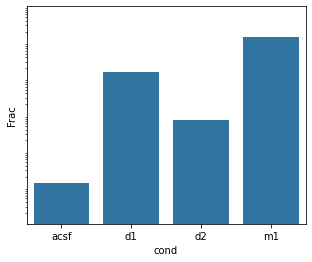

In [ ]:
frac_d1_inh   =  np.mean(var_exp_totals_inh_d1[var_exp_totals_inh_d1.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_inh_d1[var_exp_totals_inh_d1.Space=='Specific']['Variance explained'].to_numpy())
frac_d2_inh   =  np.mean(var_exp_totals_inh_d2[var_exp_totals_inh_d2.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_inh_d2[var_exp_totals_inh_d2.Space=='Specific']['Variance explained'].to_numpy())
frac_m1_inh   =  np.mean(var_exp_totals_inh_m1[var_exp_totals_inh_m1.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_inh_m1[var_exp_totals_inh_m1.Space=='Specific']['Variance explained'].to_numpy())
# frac_acsf_inh =  np.mean(var_exp_totals_inh[var_exp_totals_inh.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_inh[var_exp_totals_inh.Space=='Specific']['Variance explained'].to_numpy())




frac_d1_exc   =  np.mean(var_exp_totals_exc_d1[var_exp_totals_exc_d1.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_exc_d1[var_exp_totals_exc_d1.Space=='Specific']['Variance explained'].to_numpy())
frac_d2_exc   =  np.mean(var_exp_totals_exc_d2[var_exp_totals_exc_d2.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_exc_d2[var_exp_totals_exc_d2.Space=='Specific']['Variance explained'].to_numpy())
frac_m1_exc   =  np.mean(var_exp_totals_exc_m1[var_exp_totals_exc_m1.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_exc_m1[var_exp_totals_exc_m1.Space=='Specific']['Variance explained'].to_numpy())
# frac_acsf_exc =  np.mean(var_exp_totals_exc[var_exp_totals_exc.Space=='Shared']['Variance explained'].to_numpy()/var_exp_totals_exc[var_exp_totals_exc.Space=='Specific']['Variance explained'].to_numpy())

frac_d1_exc_acsf   =  np.mean(temp_exc_all_mean[temp_exc_all_mean.Space=='Shared']['Variance explained'].to_numpy()/temp_exc_all_mean[temp_exc_all_mean.Space=='Specific']['Variance explained'].to_numpy())

frac_d1_inh_acsf   =  np.mean(temp_inh_all_mean[temp_inh_all_mean.Space=='Shared']['Variance explained'].to_numpy()/temp_inh_all_mean[temp_inh_all_mean.Space=='Specific']['Variance explained'].to_numpy())

frac_d1_exc_acsf_std   =  np.mean(temp_exc_all_std[temp_exc_all_std.Space=='Shared']['Variance explained'].to_numpy()/temp_exc_all_std[temp_exc_all_std.Space=='Specific']['Variance explained'].to_numpy())
frac_d1_inh_acsf_std   =  np.mean(temp_inh_all_std[temp_inh_all_std.Space=='Shared']['Variance explained'].to_numpy()/temp_inh_all_std[temp_inh_all_std.Space=='Specific']['Variance explained'].to_numpy())




df_frac = {'Frac':[frac_d1_inh_acsf,
                   frac_d1_inh,
                   frac_d2_inh,
                   frac_m1_inh,
                   frac_d1_exc_acsf,
                   frac_d1_exc,
                   frac_d2_exc,
                   frac_m1_exc],
   }

df_frac = pd.DataFrame(df_frac)
df_frac['cond'] = ['acsf',
                   'd1',
                   'd2',
                   'm1',
                   'acsf',
                   'd1',
                   'd2',
                   'm1']
df_frac['cell_type'] = ['inh','inh','inh','inh','exc','exc','exc','exc']
df_frac['error'] = [frac_d1_inh_acsf_std,0,0,0,frac_d1_exc_acsf_std,0,0,0]

fig,ax = plt.subplots(figsize=(5,4))

sns.barplot(data=df_frac[df_frac.cell_type=='exc'],x='cond',y='Frac',ax=ax,log_scale=True,bottom=0.1 )
ax.set_yscale('log')
ax.set(ylim=(0.1, 100000))
plt.errorbar(x='cond',y='Frac', yerr=df_frac['error'], fmt='none', c='k', capsize=5)
plt.savefig('G:/My Drive/Data For Publication/paper2/part1/frac_shared_specific_exc_bootstrapped.pdf',dpi=200,bbox_inches='tight')
plt.show()
fig,ax = plt.subplots(figsize=(5,4))

sns.barplot(data=df_frac[df_frac.cell_type=='inh'],x='cond',y='Frac',ax=ax,log_scale=True,bottom=0.1)
# plt.yscale('log')

ax.set(ylim=(0.1, 100000))
ax.set_yscale('log')
plt.savefig('G:/My Drive/Data For Publication/paper2/part1/frac_shared_specific_inh_bootstrapped.pdf',dpi=200,bbox_inches='tight')
plt.show()


In [ ]:
{'Frac':[frac_d1_inh_acsf,
                   frac_d1_inh,
                   frac_d2_inh,
                   frac_m1_inh,
                   frac_d1_exc_acsf,
                   frac_d1_exc,
                   frac_d2_exc,
                   frac_m1_exc],}
pd.DataFrame(df_frac)

,Frac
0,1.598475
1,12.539483
2,6.003959
3,3.020562
4,1.257743
5,1516.760376
6,71.004539
7,13893.416016


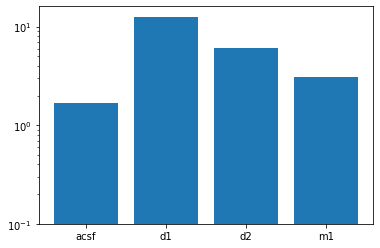

AttributeError: Rectangle.set() got an unexpected keyword argument 'error_bar'

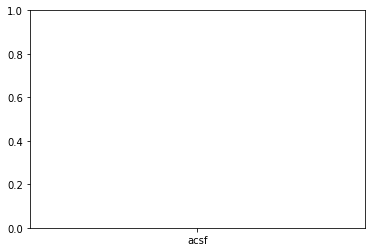

In [ ]:
# plt.bar(data=df_frac[df_frac.cell_type=='exc'],x='cond',y='Frac',ax=ax)
plt.bar(data=df_frac[df_frac.cell_type=='inh'],x='cond',height='Frac',bottom=0.1)
plt.ylim=(0.1, 10000)
plt.yscale('log')

plt.savefig('G:/My Drive/Data For Publication/paper2/part1/frac_shared_specific_inh.pdf',dpi=200,bbox_inches='tight')
plt.show()
plt.bar(data=df_frac[df_frac.cell_type=='exc'],x='cond',height='Frac',bottom=0.1,error_bar = [0.13,0,0,0])
plt.yscale('log')
plt.ylim=(0.1, 10000)

plt.savefig('G:/My Drive/Data For Publication/paper2/part1/frac_shared_specific_exc.pdf',dpi=200,bbox_inches='tight')
plt.show()
